In [1]:
import xarray as xr
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import cmocean

In [2]:
ds = xr.open_dataset("/ocean/cstang/MOAD/analysis-camryn/OAE/DyeTracing/Nanaimo/wastewaterNanaimo_20240601_wNutrients_Adjusted.nc")
ds

<xarray.Dataset> Size: 520MB
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * y                (y) int64 7kB 0 1 2 3 4 5 6 ... 891 892 893 894 895 896 897
  * x                (x) int64 3kB 0 1 2 3 4 5 6 ... 391 392 393 394 395 396 397
  * time_counter     (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 1MB ...
    nav_lon          (y, x) float32 1MB ...
    area             (y, x) float64 3MB ...
    flux             (time_counter, y, x) float64 34MB ...
    temperature      (time_counter, y, x) float64 34MB ...
    NO3              (time_counter, y, x) float64 34MB ...
    ...               ...
    DON              (time_counter, y, x) float64 34MB ...
    bSi              (time_counter, y, x) float64 34MB ...
    oxygen           (time_counter, y, x) float64 34MB ...
    alkalinity       (time_counter, y, x) float64 34MB ...
    DIC              (time_counter, y, x) float64 34MB ...
    turb             (time_counter, y, x) float64 34MB ...
Attributes:
    acknowledgements:      Based on Nanaimo WWTP and climatology
    creator_email:         cstang@eoas.ubc.ca
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 wastewaterNanaimo_20240601_wNutrients_Adjusted
    comment:               wastewaterNanaimo_20240601_wNutrients_Adjusted on ...
    notebook:              Wastewater_CreateInputFiles.ipynb
    history:               [2025-10-29] File creation.

In [3]:
ds_ca = xr.open_dataset('/ocean/dtaneja/canada_wwtp_sources.nc')
ds_ca

<xarray.Dataset> Size: 520MB
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * y                (y) int64 7kB 0 1 2 3 4 5 6 ... 891 892 893 894 895 896 897
  * x                (x) int64 3kB 0 1 2 3 4 5 6 ... 391 392 393 394 395 396 397
  * time_counter     (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 1MB ...
    nav_lon          (y, x) float32 1MB ...
    area             (y, x) float64 3MB ...
    flux             (time_counter, y, x) float64 34MB ...
    temperature      (time_counter, y, x) float64 34MB ...
    NO3              (time_counter, y, x) float64 34MB ...
    ...               ...
    DON              (time_counter, y, x) float64 34MB ...
    bSi              (time_counter, y, x) float64 34MB ...
    oxygen           (time_counter, y, x) float64 34MB ...
    alkalinity       (time_counter, y, x) float64 34MB ...
    DIC              (time_counter, y, x) float64 34MB ...
    turb             (time_counter, y, x) float64 34MB ...

In [4]:
flux_nonzero = ds_ca["flux"].max(dim="time_counter") > 0
source_indices = np.argwhere(flux_nonzero.values)

print(f"Found {len(source_indices)} sources")

lon = ds_ca["nav_lon"].values
lat = ds_ca["nav_lat"].values

Found 40 sources


In [5]:
source_y = source_indices[:, 0]
source_x = source_indices[:, 1]

/tmp/ipykernel_3141287/2638209299.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


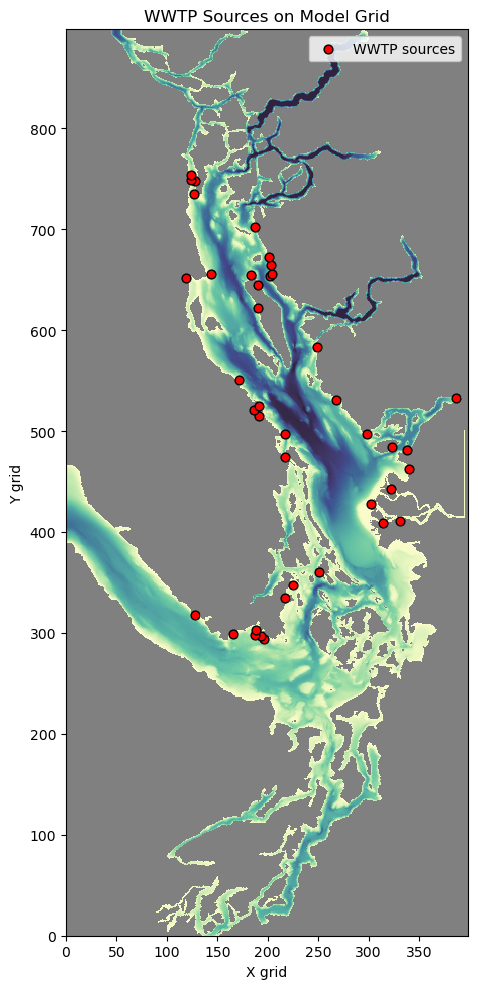

In [6]:
bathy = nc.Dataset("/ocean/atall/MOAD/grid/bathymetry_202108.nc")
bathy_data = bathy.variables["Bathymetry"][:]

mycmap = cmocean.cm.deep.copy()
mycmap.set_bad("grey")

fig, ax_map = plt.subplots(figsize=(8, 10))

mesh = ax_map.pcolormesh(bathy_data,cmap=mycmap,vmin=0,vmax=450,shading="auto")
ax_map.scatter(source_x,source_y,color="red",edgecolors="black",s=40,label="WWTP sources")
ax_map.set_title("WWTP Sources on Model Grid")

ax_map.set_xlabel("X grid")
ax_map.set_ylabel("Y grid")
ax_map.set_xlim(0, bathy_data.shape[1])
ax_map.set_ylim(0, bathy_data.shape[0])
ax_map.set_aspect("equal")
ax_map.legend()
plt.tight_layout()
plt.show()

bathy.close()

In [7]:
flux_nonzero_nanaimo = ds["flux"].max(dim="time_counter") > 0
source_indices_nanaimo = np.argwhere(flux_nonzero_nanaimo .values)

nanaimo_y = source_indices_nanaimo[:, 0]
nanaimo_x = source_indices_nanaimo[:, 1]

print(f"Found {len(source_indices_nanaimo)} source in ds")
print("Single source grid index:", source_indices_nanaimo)

Found 1 source in ds
Single source grid index: [[498 215]]


/tmp/ipykernel_3141287/3478467950.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


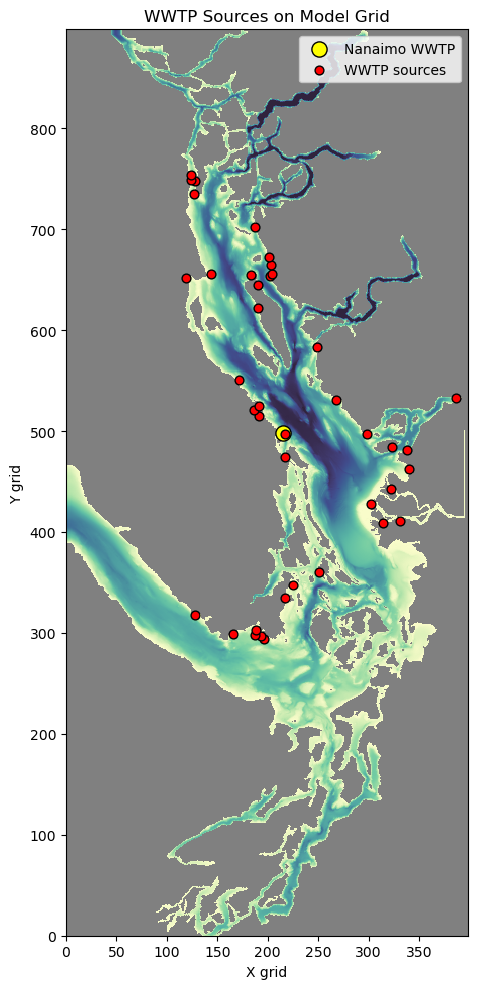

In [8]:
bathy = nc.Dataset("/ocean/atall/MOAD/grid/bathymetry_202108.nc")
bathy_data = bathy.variables["Bathymetry"][:]

mycmap = cmocean.cm.deep.copy()
mycmap.set_bad("grey")

fig, ax_map = plt.subplots(figsize=(8, 10))

mesh = ax_map.pcolormesh(bathy_data,cmap=mycmap,vmin=0,vmax=450,shading="auto")
ax_map.scatter(nanaimo_x,nanaimo_y,color="yellow",edgecolors="black",s=120,label="Nanaimo WWTP")
ax_map.scatter(source_x,source_y,color="red",edgecolors="black",s=40,label="WWTP sources")
ax_map.set_title("WWTP Sources on Model Grid")

ax_map.set_xlabel("X grid")
ax_map.set_ylabel("Y grid")
ax_map.set_xlim(0, bathy_data.shape[1])
ax_map.set_ylim(0, bathy_data.shape[0])
ax_map.set_aspect("equal")
ax_map.legend()
plt.tight_layout()
plt.show()

bathy.close()

In [9]:
ds_ca, ds = xr.align(ds_ca, ds, join="exact")

In [10]:
nanaimo_mask = (ds["flux"].fillna(0).max(dim="time_counter") > 0)
nanaimo_indices = np.argwhere(nanaimo_mask.values)
print("Nanaimo location(s) in ds [y, x]:",nanaimo_indices)

Nanaimo location(s) in ds [y, x]: [[498 215]]


In [11]:
ca_source_mask = (ds_ca["flux"].fillna(0).max(dim="time_counter") > 0)
overlap = ca_source_mask & nanaimo_mask
print("Number of overlapping source cells:", int(overlap.sum()))

Number of overlapping source cells: 0


In [12]:
mesh_mask_nc = "/ocean/atall/MOAD/grid/mesh_mask_202310b.nc"
ds_mask = xr.open_dataset(mesh_mask_nc)

rho = 1000
seconds_per_day = 86400

In [13]:
j = int(nanaimo_indices[0, 0])
i = int(nanaimo_indices[0, 1])

print(f"Nanaimo grid cell: j={j}, i={i}")

Nanaimo grid cell: j=498, i=215


In [14]:
cell_area = (
    ds_mask["e1t"].isel(t=0).values[j, i]
    * ds_mask["e2t"].isel(t=0).values[j, i]
)

print("Nanaimo cell area:", cell_area, "m²")

Nanaimo cell area: 215080.5406362431 m²


In [15]:
flux_m3d = np.array([48960,38196,38693,31203,29092,28800,27926,27800,28057,30724,45818,47561])

In [16]:
new_flux = (flux_m3d * rho/ (cell_area * seconds_per_day))
print("Cell area:", cell_area)
print("New flux:", new_flux)

Cell area: 215080.5406362431
New flux: [0.00263467 0.00205543 0.00208218 0.00167912 0.00156552 0.00154981
 0.00150277 0.00149599 0.00150982 0.00165334 0.00246559 0.00255939]


In [17]:
ds["flux"].values[:, j, i] = new_flux

In [18]:
print("Updated Nanaimo flux:")
print(ds["flux"].isel(y=j, x=i).values)

Updated Nanaimo flux:
[0.00263467 0.00205543 0.00208218 0.00167912 0.00156552 0.00154981
 0.00150277 0.00149599 0.00150982 0.00165334 0.00246559 0.00255939]


In [19]:
ds_all = ds_ca.copy(deep=True)

for var in ds.data_vars:
    if "time_counter" in ds[var].dims:
        attrs = ds_ca[var].attrs.copy()
        ds_all[var] = xr.where(nanaimo_mask,ds[var],ds_ca[var])
        ds_all[var].attrs = attrs

In [20]:
combined_source_mask = (ds_all["flux"].fillna(0).max(dim="time_counter") > 0)
print("Sources originally in ds_ca:", int(ca_source_mask.sum()))
print("Sources in ds:", int(nanaimo_mask.sum()))
print("Sources in combined dataset:", int(combined_source_mask.sum()))

Sources originally in ds_ca: 40
Sources in ds: 1
Sources in combined dataset: 41


In [21]:
for y, x in nanaimo_indices:
    print(f"Inserted source at y={y}, x={x}")
    print(ds_all.isel(y=y, x=x))

Inserted source at y=498, x=215
<xarray.Dataset> Size: 2kB
Dimensions:          (time_counter: 12)
Coordinates:
  * time_counter     (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    y                int64 8B 498
    x                int64 8B 215
Data variables: (12/18)
    nav_lat          float32 4B 49.23
    nav_lon          float32 4B -123.9
    area             float64 8B ...
    flux             (time_counter) float64 96B 0.002635 0.002055 ... 0.002559
    temperature      (time_counter) float64 96B 14.65 14.54 ... 16.22 15.17
    NO3              (time_counter) float64 96B 322.0 322.0 ... 322.0 322.0
    ...               ...
    DON              (time_counter) float64 96B 102.0 102.0 ... 102.0 102.0
    bSi              (time_counter) float64 96B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    oxygen           (time_counter) float64 96B 184.0 184.0 ... 184.0 184.0
    alkalinity       (time_counter) float64 96B 2.118e+03 ... 2.118e+03
    DIC              (time_counter) float64 96B 2.

In [22]:
output_path = "/ocean/dtaneja/MOAD/analysis-dishika/canada_wwtp_sources_with_nanaimo.nc"
encoding = {}
for var in ds_all.data_vars:
    encoding[var] = {"zlib": True,"complevel": 4}

ds_all.to_netcdf(output_path,encoding=encoding)
print("Saved combined dataset:", output_path)

Saved combined dataset: /ocean/dtaneja/MOAD/analysis-dishika/canada_wwtp_sources_with_nanaimo.nc
